### SHAP - GPU -version

In [66]:
import pandas as pd
df = pd.read_csv("housing_trimmed_variables.csv")

df.head()

,housing_median_age,total_rooms,population,median_income,median_house_value,distance_to_nearest_city,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY
0,41.0,880.0,322.0,8.3252,452600.0,20.33,0,0,0,1
1,21.0,7099.0,2401.0,8.3014,358500.0,19.91,0,0,0,1
2,52.0,1467.0,496.0,7.2574,352100.0,17.84,0,0,0,1
3,52.0,1274.0,558.0,5.6431,341300.0,17.06,0,0,0,1
4,52.0,1627.0,565.0,3.8462,342200.0,17.06,0,0,0,1


In [67]:
df.columns

Index(['housing_median_age', 'total_rooms', 'population', 'median_income',
       'median_house_value', 'distance_to_nearest_city',
       'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY'],
      dtype='object')

In [68]:
# remove special characters
df.columns = (
    df.columns
    .str.replace('<', '', regex=False)
    .str.replace('>', '', regex=False)
    .str.replace('[', '', regex=False)
    .str.replace(']', '', regex=False)
    .str.replace(' ', '_', regex=False)
)

In [69]:
df.columns

Index(['housing_median_age', 'total_rooms', 'population', 'median_income',
       'median_house_value', 'distance_to_nearest_city',
       'ocean_proximity_1H_OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR_BAY'],
      dtype='object')

Feature Importances using SHAP:
                    Feature    Importance
0        housing_median_age   5294.538195
1               total_rooms  12796.194014
2                population  10204.404962
3             median_income  41880.309494
4  distance_to_nearest_city  19017.727313
5  ocean_proximity_1H_OCEAN   3263.509775
6    ocean_proximity_INLAND  30499.459734
7    ocean_proximity_ISLAND     19.679909
8  ocean_proximity_NEAR_BAY   2277.296334


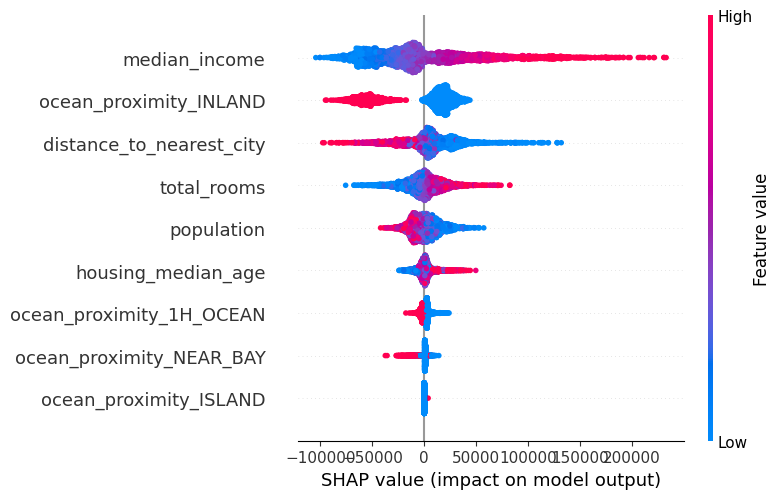

In [70]:
import shap
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Define features and target
X = df[['housing_median_age', 'total_rooms', 'population', 'median_income',
        'distance_to_nearest_city',
       'ocean_proximity_1H_OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR_BAY']]

y = df['median_house_value']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Train model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Initialize SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Plot SHAP summary
shap.summary_plot(shap_values, X_test, show=False)

# Feature importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.mean(np.abs(shap_values), axis=0)
})

print("Feature Importances using SHAP:")
print(importance)